## Diffusion model: Exponential Decay Cosine Dataset

Author: diego.camarero@estudiante.uam.es

In [ ]:
experiment_number = '15'

kernel_sizes = (9, 9, 9, 9)

lambda_min = 0.05
lambda_max = 2.5

dataset_size = 2000

epoch_to_load = 1000

experiment_name = f"training_diffusion_{experiment_number}_ExponentialDecayCosine_{dataset_size}"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Scalar diffusion/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Scalar diffusion/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import diffusion.diffusion_process as dfp

from models.score_model import UNetScoreModel

from data.functional_dataset import (
    ExponentialDecayCosineDataset,
)

from utils.metrics import (
    fit_dataset,
    parametric_model,
    residual_MSE,
    wasserstein_uniform_vs_samples,
    plot_hist_vs_uniform,
    plot_metric_distributions,
    plot_mse_histogram,
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_ou_diffusion_process,
    plot_distribution_convergence,
)

In [ ]:
from pathlib import Path
from datetime import datetime

RESULTS_DATA_DIR = Path("../../results/data")
RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_tensor_bundle(filename, **kwargs):
    payload = {"timestamp": datetime.now().isoformat()}
    for k, v in kwargs.items():
        payload[k] = v.detach().cpu() if torch.is_tensor(v) else v

    path = RESULTS_DATA_DIR / filename
    torch.save(payload, path)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved -> {path}  ({size_mb:.2f} MB)")
    return path

## Dataset creation

torch.Size([8, 1, 128])


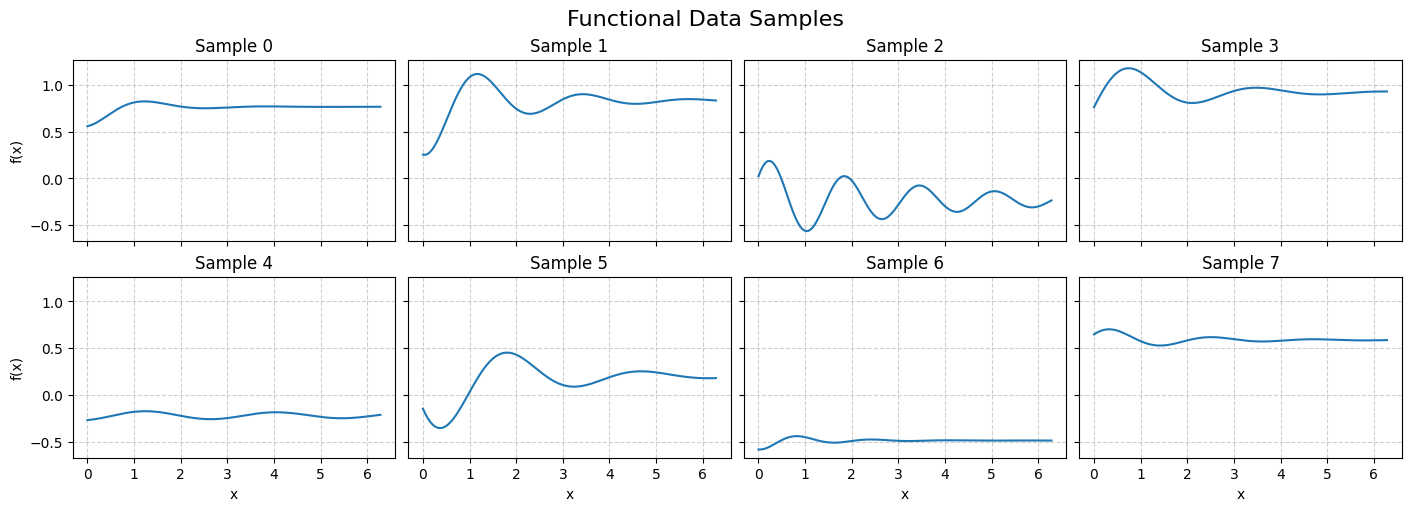

In [ ]:
# Create functional dataset

M = 128
N = dataset_size
x_inf, x_sup = 0.0, 2*torch.pi

a_min, a_max = -1.0, 1.0
b_min, b_max = -1.0, 1.0
alpha_min, alpha_max = 0.1, 1.0
w_min, w_max = 2.0, 4.0
phase_min, phase_max = -torch.pi / 2.0, torch.pi / 2.0

theta_min = [a_min, b_min, alpha_min, w_min, phase_min]
theta_max = [a_max, b_max, alpha_max, w_max, phase_max]

data_train = ExponentialDecayCosineDataset(
    N, n_points=M, x_inf=x_inf, x_sup=x_sup, seed=seed,
    a_min=a_min, a_max=a_max, b_min=b_min, b_max=b_max, alpha_min=alpha_min, alpha_max=alpha_max,
    w_min=w_min, w_max=w_max, phase_min=phase_min, phase_max=phase_max,
)

# Plot some examples of the dataset
n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x = data_train.axis_x,
)

In [ ]:
# save training dataset
save_tensor_bundle(
    "dataset_samples.pt",
    data=data_train.data,
    seed=seed,
    x_inf=x_inf,
    x_sup=x_sup,
    theta_min=theta_min,
    theta_max=theta_max,
    theta_true=data_train.parameters,
)

Saved -> ../../results/data/dataset_samples.pt  (1.07 MB)


PosixPath('../../results/data/dataset_samples.pt')

## Diffusion process

In [ ]:
t_0 = 0.0
T = 1.0
t_eps = 1.0e-3

lambda_t = lambda t: lambda_min + (t-t_0) / (T-t_0) * (lambda_max - lambda_min)

def drift_coefficient(x_t, t):
    t = t.view(-1, 1, 1)
    return - lambda_t(t) * x_t

def diffusion_coefficient(t):
    t = t.view(-1, 1, 1)
    return torch.sqrt(2 * lambda_t(t))

def mu_t(x_0, t):
    return x_0 * torch.exp(-lambda_min*(t-t_0) - (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

def sigma_t(t):
    return torch.sqrt(1 - torch.exp(-2 * lambda_min * (t-t_0) - (t-t_0)**2 /(T-t_0) * (lambda_max - lambda_min)))

def inverse_mu_t(t):
    return torch.exp(lambda_min*(t-t_0) + (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([2000, 100, 1, 128])


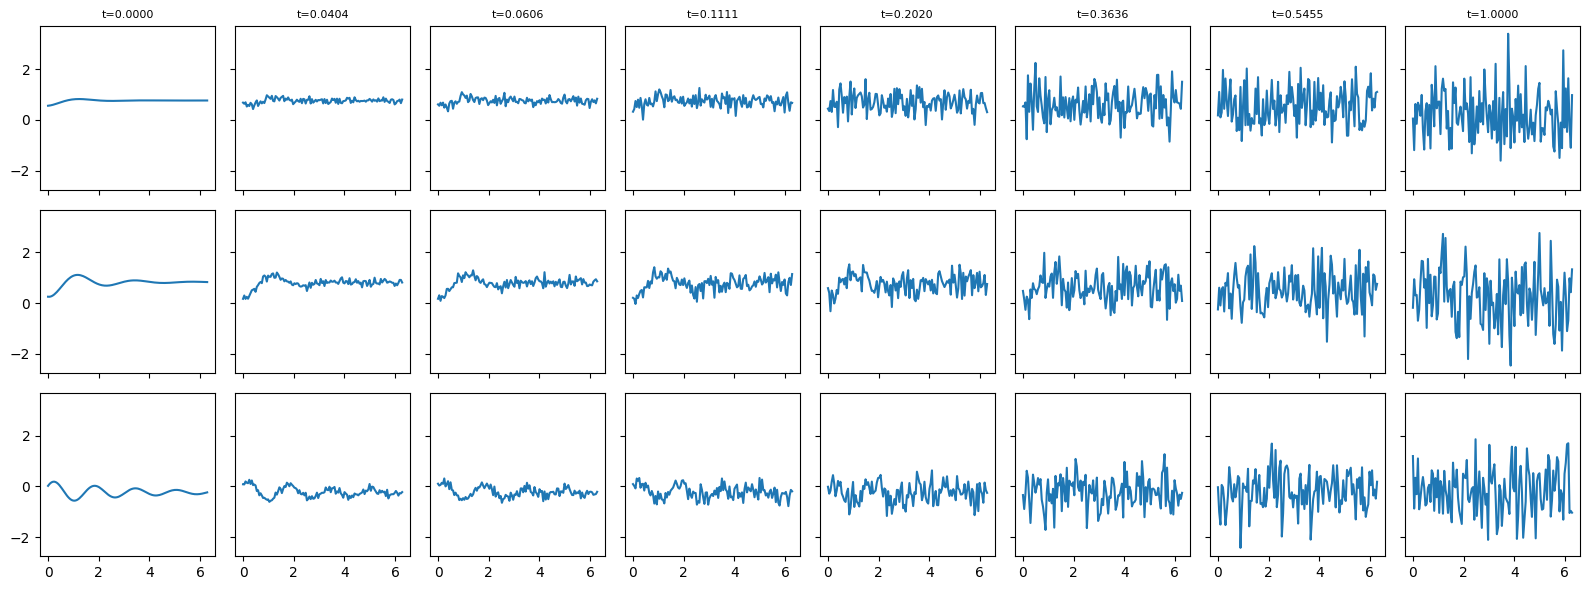

In [ ]:
torch.manual_seed(seed)
n_steps = 100
times, X = dfp.euler_maruyama_integrator(
    x_initial=data_train[:].to(device),
    t_start=t_0,
    t_end=T,
    n_times=n_steps,
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
)
print(X.shape)

plot_ou_diffusion_process(
    X,
    data_train.axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

In [ ]:
# Save forward diffusion process
save_tensor_bundle(
    "forward_diffusion_process.pt",
    data=X,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

Saved -> ../../results/data/forward_diffusion_process.pt  (102.40 MB)


PosixPath('../../results/data/forward_diffusion_process.pt')

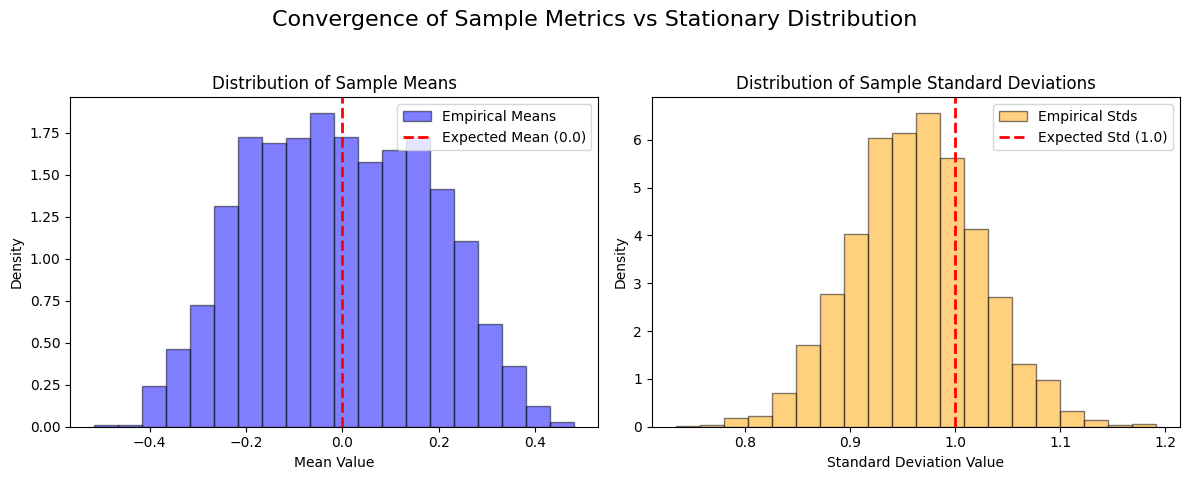

In [ ]:
plot_distribution_convergence(
    X,
    loc_stationary=0.0,
    scale_stationary=1.0,
)

## Synthetic data generation

In [ ]:
# Define the score model

def multiply_inv_sigma(h,t):
    h = h / sigma_t(t)[:, None]
    return h

score_model = UNetScoreModel(
    multiply_inv_sigma=multiply_inv_sigma,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

In [ ]:
# Compute results

checkpoint_path = os.path.join(
    CHECKPOINTS_DIR,
    experiment_name,
    f"checkpoint_epoch_{epoch_to_load}.pth"
)

def backward_drift_coefficient(x_t, t, drift_coefficient, diffusion_coefficient, score_model):
    score = score_model(x_t, t)
    return drift_coefficient(x_t, t) - diffusion_coefficient(t).view(-1, 1, 1) ** 2 * score

n_functions = 2000
torch.manual_seed(seed)
noise_T = torch.randn(n_functions, 1, M, device=device)

score_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(checkpoint_path, score_model, optimizer)
score_model.eval()

torch.manual_seed(seed)
with torch.no_grad():
    times, synthetic_functions_t = dfp.euler_maruyama_integrator(
        x_initial=noise_T,
        t_start=T,
        t_end=t_0 + t_eps,
        n_times=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            drift_coefficient=drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
            score_model=score_model,
            ),
        diffusion_coefficient=diffusion_coefficient,
    )

    synthetic_functions = dfp.inverse_Tweedie_formula(
            x_t=synthetic_functions_t[:, -1, :, :],
            t=t_eps,
            inv_mu_t=inverse_mu_t,
            sigma_t=sigma_t,
            score_model=score_model,
        )

    synthetic_functions_t = torch.cat(
        [synthetic_functions_t, synthetic_functions.unsqueeze(1)],
        dim=1,
        )

print(synthetic_functions.shape)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Scalar diffusion/checkpoints/training_diffusion_15_ExponentialDecayCosine_2000/checkpoint_epoch_1000.pth
Epoch: 1000. Loss: 2.799687. Time: 16:43
torch.Size([2000, 1, 128])


In [ ]:
save_tensor_bundle(
    "generated_diffusion_samples.pt",
    data=synthetic_functions_t,
    seed=seed,
)

Saved -> ../../results/data/generated_diffusion_samples.pt  (103.43 MB)


PosixPath('../../results/data/generated_diffusion_samples.pt')

## Results

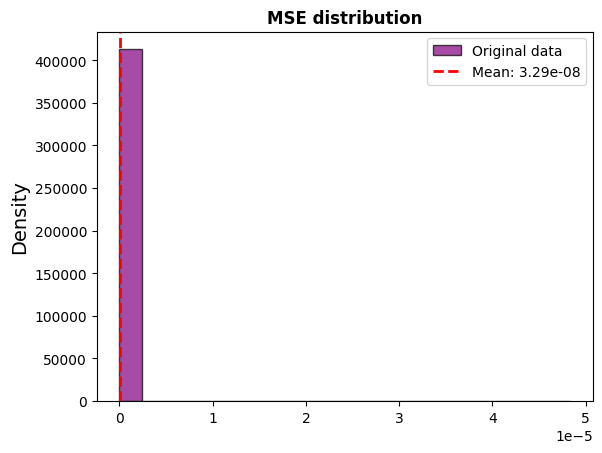

In [ ]:
# original data

data_label = "Original data"

original_theta_hat, original_mse_fit = fit_dataset(
        data_train.data,
        data_train.axis_x,
        parametric_model,
)

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

original_mses = residual_MSE(
    data_train.data,
    original_theta_hat,
    # hat_true,
    data_train.axis_x,
    parametric_model,
)

plot_mse_histogram(original_mses, data_label=data_label)

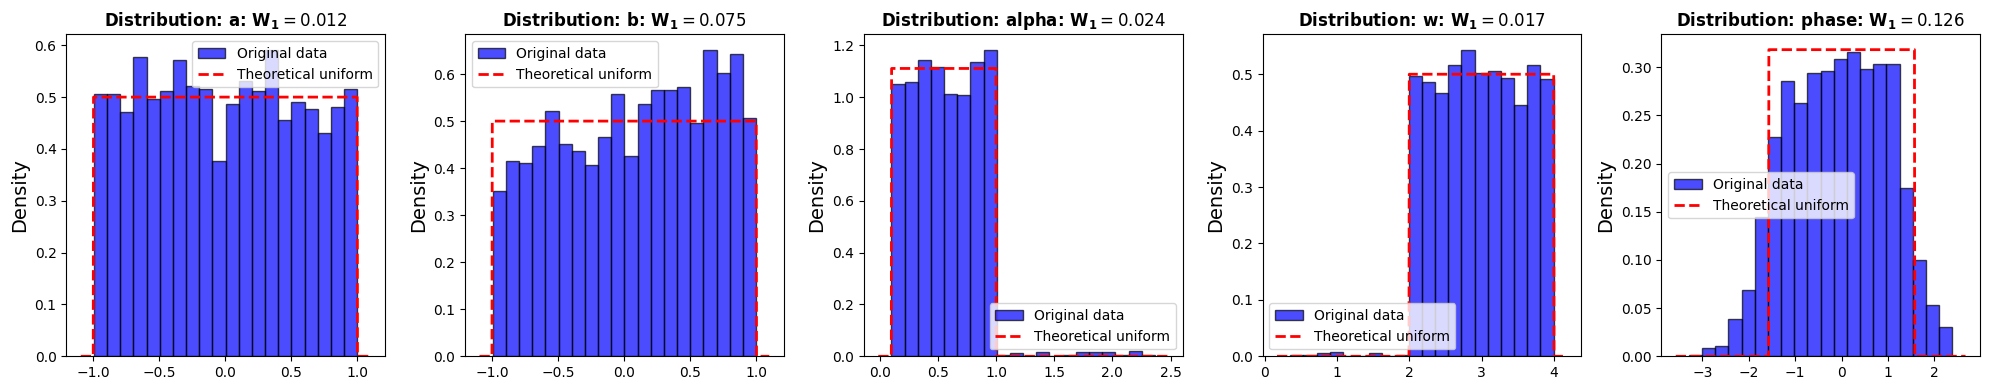

In [ ]:
# original data

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

metrics = ["wd_a", "wd_b", "wd_alpha", "wd_w", "wd_phase"]
titles = ["Distribution: a", "Distribution: b", "Distribution: alpha", "Distribution: w", "Distribution: phase"]

plot_metric_distributions(original_theta_hat, theta_min, theta_max, metrics, titles, data_label)

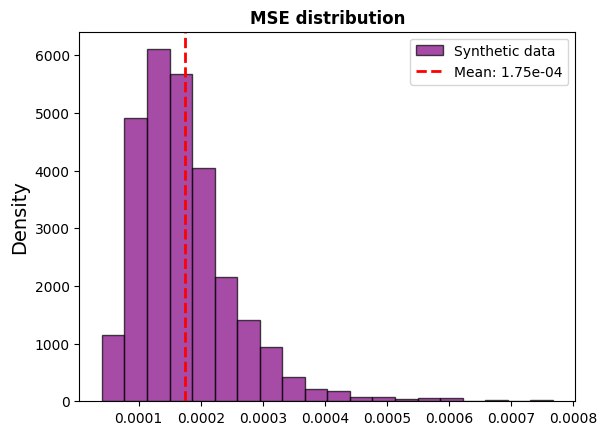

In [ ]:
# synthetic data

data_label = "Synthetic data"

theta_hat, mse_fit = fit_dataset(
        synthetic_functions,
        data_train.axis_x,
        parametric_model,
)

mses = residual_MSE(
    synthetic_functions,
    theta_hat,
    data_train.axis_x,
    parametric_model,
)

plot_mse_histogram(mses, data_label=data_label)

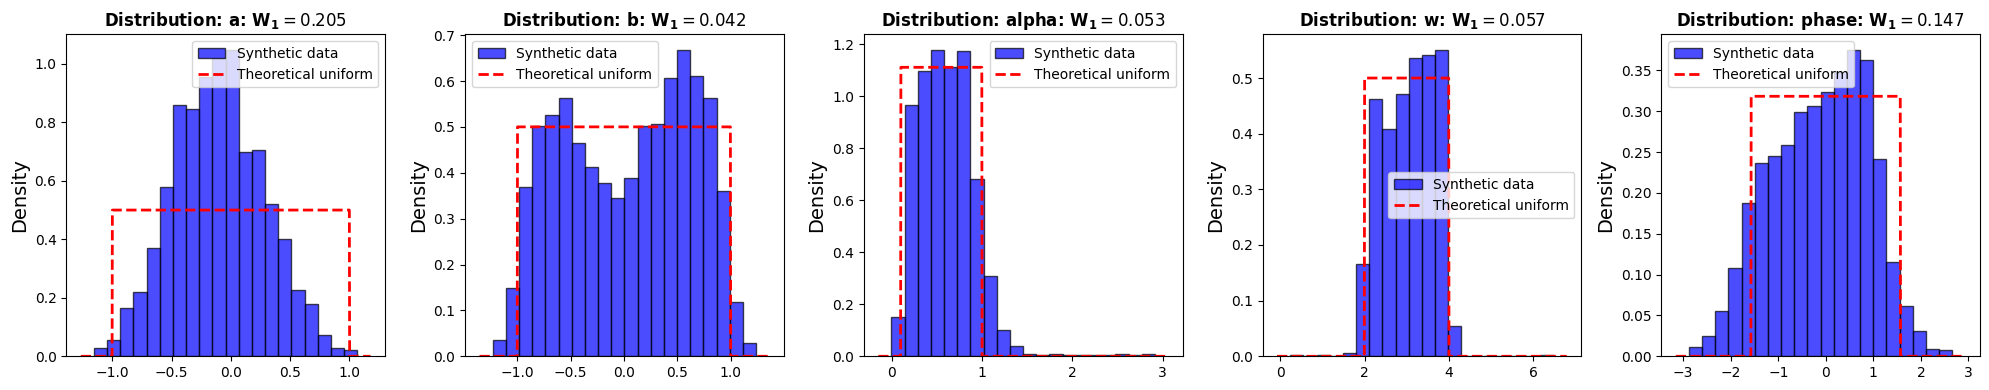

In [ ]:
# synthetic data

metrics = ["wd_a", "wd_b", "wd_alpha", "wd_w", "wd_phase"]
titles = ["Distribution: a", "Distribution: b", "Distribution: alpha", "Distribution: w", "Distribution: phase"]

plot_metric_distributions(theta_hat, theta_min, theta_max, metrics, titles, data_label=data_label)

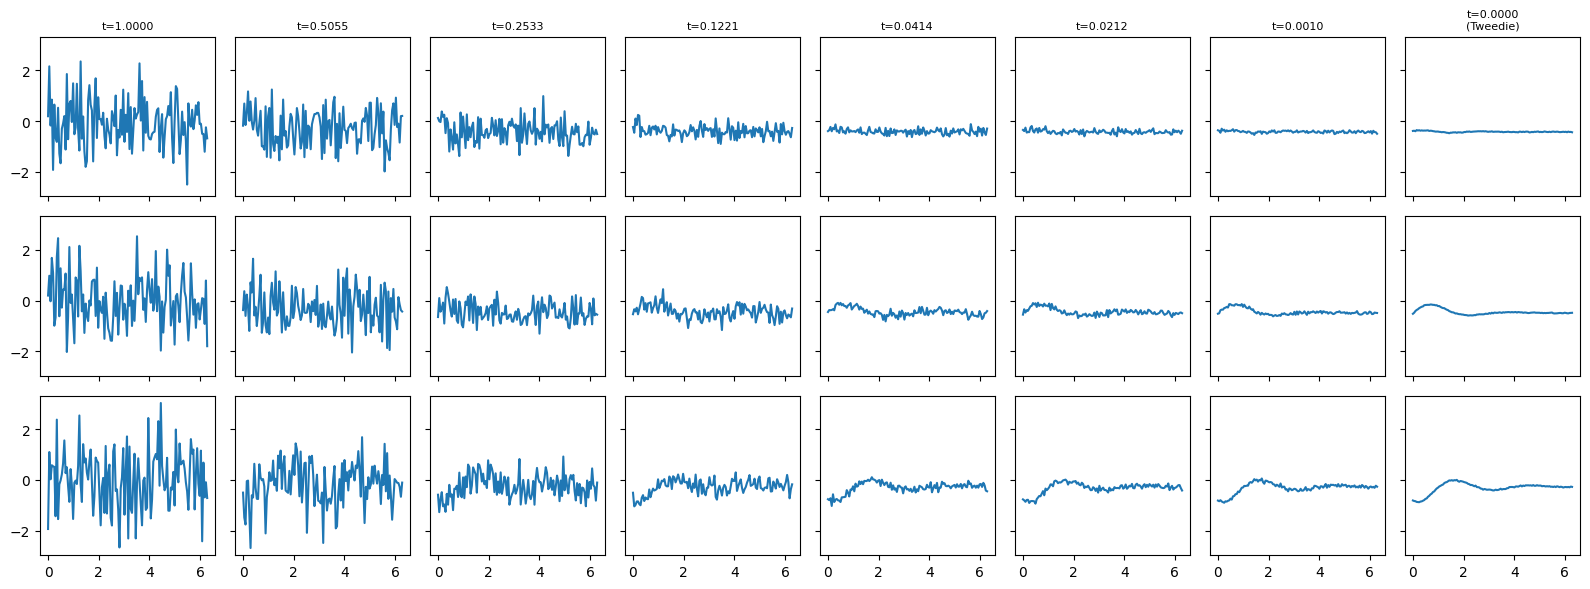

In [ ]:
plot_ou_diffusion_process(
    synthetic_functions_t,
    data_train.axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_eps,
    tweedie_final=True,
)

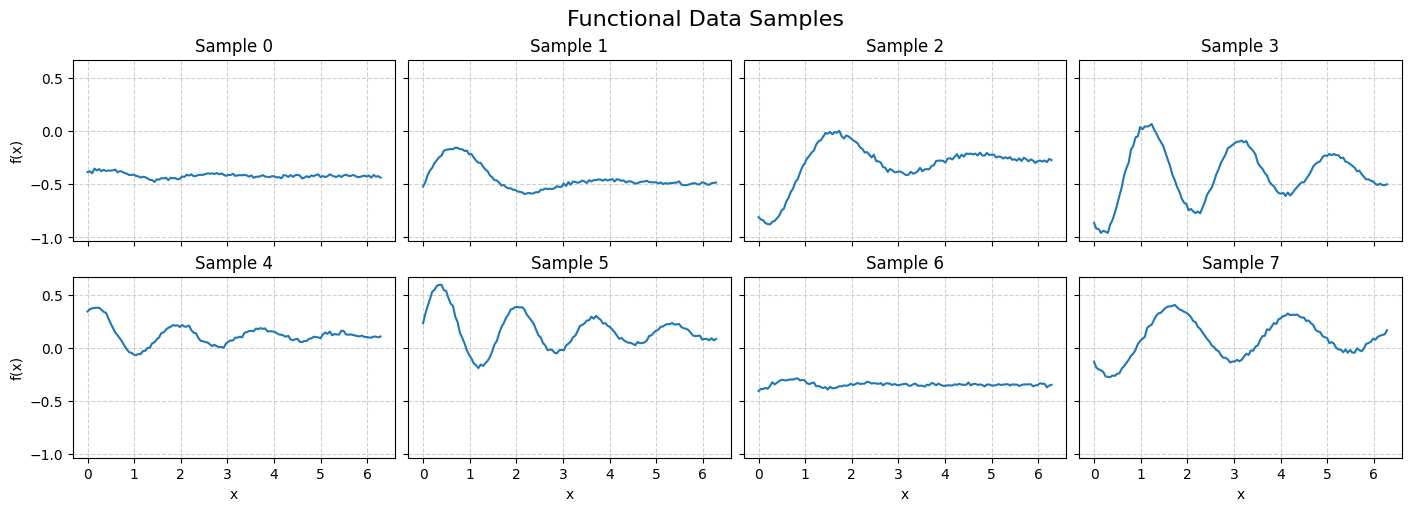

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x = data_train.axis_x,
)